In [1]:
from mc_experiment import (
    make_seed_counter,
    next_seed,
    standardize_innovations,
    summarize_reference_experiment,
    summarize_mle_augmentation_experiment,
    augmented_config_path,
)

from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.bayesian import make_prior

from numpy import log
import numpy as np

from scipy.stats import chi2, gaussian_kde, norm

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cProfile

import contextlib
import io
STDOUT_VOID = lambda: contextlib.redirect_stdout(io.StringIO())

_KNOWN_R = False
_AUGMENTED_PARAM = 'Pi_coef'
_AUGMENTED_EQUATION = 'OutGap'
_AUGMENTED_CONFIG = augmented_config_path(_AUGMENTED_EQUATION)
_MEAS_ERR_SCALE = 0.00
_MC_SAMPLES = 100_000
_MC_ALPHA = 0.05
_MC_SUMMARY_ONLY = False
_MC_INCLUDE_BY_PREDICTOR = False
_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# Load reference model
parser = ModelParser("../../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

print("Transition matrix:\n", sol.A.round(3), "\n")
print("Shock Loadings:\n", sol.B.round(3))

Transition matrix:
 [[ 0.83  -0.     0.     0.     0.   ]
 [ 0.     0.85   0.     0.     0.   ]
 [ 0.288 -0.047  0.28   0.     0.   ]
 [ 0.892  0.708 -1.711  0.     0.   ]
 [ 0.7   -0.115 -1.363  0.     0.   ]] 

Shock Loadings:
 [[ 1.     0.     0.   ]
 [ 0.     1.     0.   ]
 [ 0.     0.     1.   ]
 [ 3.193  0.493 -6.107]
 [ 2.531 -0.406 -4.864]]


In [3]:
# Load Misspecified DGP
parser_dgp = ModelParser("../../MODELS/misspec_test/misspec.yaml")
config_dgp, kalman_dgp = parser_dgp.get_all()
solver_dgp = DSGESolver(config_dgp, kalman_dgp)
comp_dgp = solver_dgp.compile(
    n_state=3,
    n_exog=3,
)
sol_dgp = solver_dgp.solve(
    comp_dgp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [4]:
# Large sample simulations used to approximate measurement-noise variances
_large_sample_seed_counter = make_seed_counter(start=100_000)
shocks_large = {
    "g,z": Shock(10_000, "norm", multivar=True, seed=next_seed(_large_sample_seed_counter)).shock_generator(),
    "r": Shock(10_000, "norm", multivar=False, seed=next_seed(_large_sample_seed_counter)).shock_generator(),
}

sim1 = sol_dgp.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

sim2 = sol.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

In [5]:
T = 200
_plot_seed_counter = make_seed_counter(start=2_000_000)

err_var = np.var(np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]]), axis=0)
mc_reference = summarize_reference_experiment(
    sol,
    sol_dgp,
    T=T,
    err_var=err_var,
    meas_err_scale=_MEAS_ERR_SCALE,
    mc_samples=_MC_SAMPLES,
    known_r=_KNOWN_R,
    alpha=_MC_ALPHA,
    summary_only=_MC_SUMMARY_ONLY,
    include_by_predictor=_MC_INCLUDE_BY_PREDICTOR,
)

rep_ref = mc_reference["representative"]
sim_dgp = rep_ref.sim_dgp
obs = rep_ref.obs
kf = rep_ref.kf
std_innov = rep_ref.std_innov
err_scale = rep_ref.err_scale
N, n_obs = kf.innov.shape

_measurement_order = {"OutGap": 0, "Infl": 1, "Rate": 2}
_predictor_order = {"Pi": 0, "x": 1, "r": 2}

def _sort_summary(df):
    out = df.copy()
    if "measurement" in out.columns:
        out["measurement_order"] = out["measurement"].map(_measurement_order)
    if "predictor" in out.columns:
        out["predictor_order"] = out["predictor"].map(_predictor_order)
    if "target" in out.columns:
        out["target_order"] = out["target"].map(_predictor_order)
    if "regressor" in out.columns:
        out["regressor_order"] = out["regressor"].map(_predictor_order)
    sort_cols = [
        col
        for col in ["measurement_order", "target_order", "predictor_order", "regressor_order"]
        if col in out.columns
    ]
    if sort_cols:
        out = out.sort_values(sort_cols)
    return out.drop(columns=[col for col in ["measurement_order", "target_order", "predictor_order", "regressor_order"] if col in out.columns])

sim_ref = sol.sim(
    T=T,
    shocks={
        "g,z": Shock(T, "norm", multivar=True, seed=next_seed(_plot_seed_counter)).shock_generator(),
        "r": Shock(T, "norm", multivar=False, seed=next_seed(_plot_seed_counter)).shock_generator(),
    },
    observables=True,
)
ref = np.column_stack([sim_ref["OutGap"], sim_ref["Infl"], sim_ref["Rate"]])[1:, :]

obs_dgp = np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]])[1:, :]
if np.any(err_scale != 0.0):
    _plot_rng = np.random.default_rng(next_seed(_plot_seed_counter))
    obs_dgp = obs_dgp + _plot_rng.normal(scale=np.sqrt(err_scale), size=obs_dgp.shape)

In [6]:
print(f"Known R assumption: {_KNOWN_R}")
print(f"Augmented measurement equation: {_AUGMENTED_EQUATION}")
print(f"Augmented coefficient: {_AUGMENTED_PARAM}")
print(f"Monte Carlo replications: {_MC_SAMPLES}")
print("Noise Covariance:\n", np.diag(err_scale).round(3))

Known R assumption: False
Augmented measurement equation: OutGap
Augmented coefficient: Pi_coef
Monte Carlo replications: 100000
Noise Covariance:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


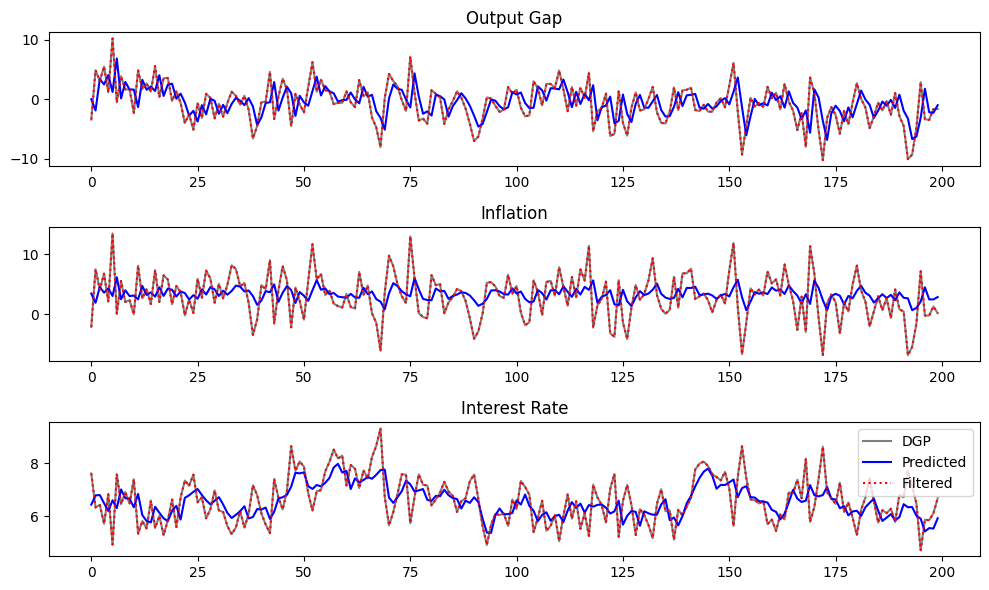

In [7]:
# Plot filter outputs for the representative draw
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.5)
ax[0].plot(range(T), kf.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.5)
ax[1].plot(range(T), kf.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.5)
ax[2].plot(range(T), kf.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

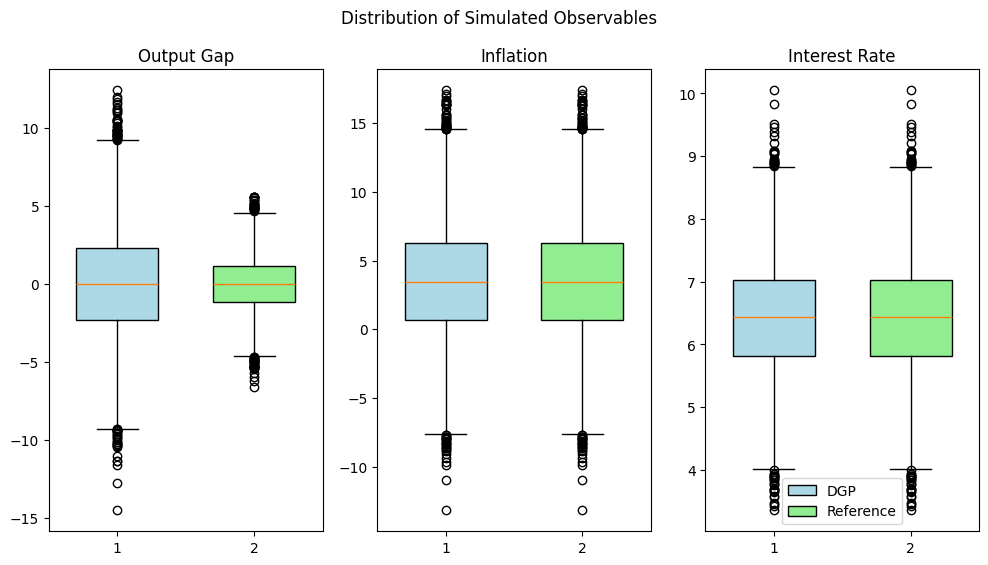

In [8]:
fig, ax = plt.subplots(1, 3, figsize=_FIGSIZE_2D)

plt.suptitle("Distribution of Simulated Observables")

ax[0].boxplot(obs_dgp[:, 0], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[0].boxplot(sim2["OutGap"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[0].set_title("Output Gap")

ax[1].boxplot(obs_dgp[:, 1], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[1].boxplot(sim2["Infl"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[1].set_title("Inflation")

ax[2].boxplot(obs_dgp[:, 2], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[2].boxplot(sim2["Rate"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[2].set_title("Interest Rate")
ax[2].legend()

In [9]:
print(f"Monte Carlo Ljung-Box summary across {_MC_SAMPLES} replications:")
mc_reference["lb_summary"].round(3)

Monte Carlo Ljung-Box summary across 100000 replications:


,measurement,lb_stat,p_value,mc_se_lb_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,OutGap,15.272,0.004,0.021,0.000,100000,98350,0.984,0.000,0.983,0.984
1,Infl,22.009,0.000,0.024,0.000,100000,99919,0.999,0.000,0.999,0.999
2,Rate,3.383,0.227,0.010,0.001,100000,34453,0.345,0.002,0.342,0.347


In [10]:
print(f"Momoent Tests summary across {_MC_SAMPLES} replications:")
display(mc_reference["moment_specification_test_summary"].round(3))

Momoent Tests summary across 100000 replications:


,test,distance,stat,p_value,mc_se_distance,mc_se_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high,df,sample_size,bandwidth
0,mean_zero_hac,0.120,2.710,0.552,0.000,0.008,0.001,100000,4942,0.049,0.001,0.048,0.051,3.0,200,4
1,cov_identity,13.788,781.796,0.000,0.005,0.994,0.000,100000,100000,1.000,0.000,1.000,1.000,6.0,200,4


In [11]:
print("Orthogonalization summary (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["orthogonalization_summary"]).round(3)

Orthogonalization summary (Monte Carlo averages and rejection rates):


,target,regressor,coef,std_error,t_stat,p_value,r2,marginal_r2,mc_se_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,mc_se_marginal_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
1,Pi,x,0.113,0.004,28.391,0.000,0.804,0.767,0.000,0.0,0.013,0.000,0.0,0.0,100000,100000,1.000,0.000,1.000,1.000
0,Pi,r,0.137,0.073,1.929,0.195,0.804,0.009,0.001,0.0,0.007,0.001,0.0,0.0,100000,52988,0.530,0.002,0.527,0.533
3,x,Pi,7.044,0.253,28.391,0.000,0.812,0.737,0.001,0.0,0.013,0.000,0.0,0.0,100000,100000,1.000,0.000,1.000,1.000
2,x,r,-1.899,0.564,-3.465,0.103,0.812,0.017,0.004,0.0,0.008,0.001,0.0,0.0,100000,73550,0.736,0.001,0.733,0.738
5,r,Pi,0.129,0.068,1.929,0.195,0.113,0.037,0.000,0.0,0.007,0.001,0.0,0.0,100000,52988,0.530,0.002,0.527,0.533
4,r,x,-0.029,0.009,-3.465,0.103,0.113,0.075,0.000,0.0,0.008,0.001,0.0,0.0,100000,73550,0.736,0.001,0.733,0.738


In [12]:
print("Innovations on orthogonalized predicted states (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["measurement_regressions_orthogonalized_summary"]).round(3)

Innovations on orthogonalized predicted states (Monte Carlo averages and rejection rates):


,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2,mc_se_coef,mc_se_standardized_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,OutGap,Pi,-4.027,-0.143,1.979,-2.054,0.133,0.025,0.006,0.0,0.001,0.003,0.001,0.0,100000,53355,0.534,0.002,0.530,0.537
1,OutGap,x,-0.051,-0.013,0.254,-0.184,0.511,0.005,0.001,0.0,0.000,0.003,0.001,0.0,100000,4234,0.042,0.001,0.041,0.044
2,OutGap,r,-0.455,-0.014,2.064,-0.200,0.509,0.005,0.006,0.0,0.001,0.003,0.001,0.0,100000,4239,0.042,0.001,0.041,0.044
3,Infl,Pi,-0.200,-0.004,2.304,-0.060,0.496,0.005,0.007,0.0,0.001,0.003,0.001,0.0,100000,5351,0.054,0.001,0.052,0.055
4,Infl,x,-0.003,-0.001,0.293,-0.009,0.495,0.005,0.001,0.0,0.000,0.003,0.001,0.0,100000,5348,0.053,0.001,0.052,0.055
5,Infl,r,-0.406,-0.010,2.378,-0.148,0.492,0.005,0.008,0.0,0.001,0.003,0.001,0.0,100000,5460,0.055,0.001,0.053,0.056
6,Rate,Pi,0.073,0.011,0.424,0.152,0.495,0.005,0.001,0.0,0.000,0.003,0.001,0.0,100000,5450,0.054,0.001,0.053,0.056
7,Rate,x,0.000,0.000,0.054,0.002,0.497,0.005,0.000,0.0,0.000,0.003,0.001,0.0,100000,5229,0.052,0.001,0.051,0.054
8,Rate,r,-0.033,-0.004,0.438,-0.057,0.495,0.005,0.001,0.0,0.000,0.003,0.001,0.0,100000,5287,0.053,0.001,0.052,0.054


In [13]:
print("Innovations on raw predicted states (Monte Carlo averages and rejection rates):")
_sort_summary(mc_reference["measurement_regressions_raw_summary"]).round(3)

Innovations on raw predicted states (Monte Carlo averages and rejection rates):


,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2,mc_se_coef,mc_se_standardized_coef,mc_se_std_error,mc_se_t_stat,mc_se_p_value,mc_se_r2,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
2,OutGap,Pi,-4.246,-0.345,0.815,-5.194,0.000,0.122,0.003,0.0,0.000,0.003,0.000,0.0,100000,99989,1.000,0.000,1.000,1.000
1,OutGap,x,-0.478,-0.312,0.102,-4.638,0.001,0.100,0.000,0.0,0.000,0.003,0.000,0.0,100000,99902,0.999,0.000,0.999,0.999
0,OutGap,r,1.410,0.050,1.939,0.712,0.480,0.005,0.004,0.0,0.001,0.002,0.001,0.0,100000,3214,0.032,0.001,0.031,0.033
5,Infl,Pi,-0.046,-0.002,1.000,-0.026,0.503,0.005,0.003,0.0,0.000,0.003,0.001,0.0,100000,4855,0.049,0.001,0.047,0.050
4,Infl,x,-0.006,-0.002,0.124,-0.025,0.502,0.005,0.000,0.0,0.000,0.003,0.001,0.0,100000,4867,0.049,0.001,0.047,0.050
3,Infl,r,-0.221,-0.006,2.235,-0.089,0.497,0.005,0.007,0.0,0.001,0.003,0.001,0.0,100000,5044,0.050,0.001,0.049,0.052
8,Rate,Pi,0.052,0.019,0.184,0.266,0.494,0.005,0.001,0.0,0.000,0.003,0.001,0.0,100000,5639,0.056,0.001,0.055,0.058
7,Rate,x,0.006,0.018,0.023,0.250,0.494,0.005,0.000,0.0,0.000,0.003,0.001,0.0,100000,5534,0.055,0.001,0.054,0.057
6,Rate,r,-0.053,-0.007,0.411,-0.098,0.501,0.005,0.001,0.0,0.000,0.003,0.001,0.0,100000,4833,0.048,0.001,0.047,0.050


In [14]:
print("Innovation decomposition on orthogonalized predicted states (Monte Carlo averages):")
_sort_summary(mc_reference["innovation_decomposition_orthogonalized_summary"]).round(3)

Innovation decomposition on orthogonalized predicted states (Monte Carlo averages):


,measurement,predictor,beta_measurement_error,beta_state_prediction_error,beta_total_innovation,beta_component_sum,beta_component_gap,abs_beta_component_gap,reconstruction_max_abs_error,mc_se_beta_measurement_error,mc_se_beta_state_prediction_error,mc_se_beta_total_innovation,mc_se_beta_component_sum,mc_se_beta_component_gap,mc_se_abs_beta_component_gap,mc_se_reconstruction_max_abs_error
0,OutGap,Pi,1.900,-5.927,-4.027,-4.027,0.0,0.0,0.0,0.004,0.003,0.006,0.006,0.0,0.0,0.0
1,OutGap,x,-0.002,-0.050,-0.051,-0.051,-0.0,0.0,0.0,0.000,0.000,0.001,0.001,0.0,0.0,0.0
2,OutGap,r,-0.203,-0.252,-0.455,-0.455,-0.0,0.0,0.0,0.004,0.003,0.006,0.006,0.0,0.0,0.0
3,Infl,Pi,0.000,-0.200,-0.200,-0.200,-0.0,0.0,0.0,0.000,0.007,0.007,0.007,0.0,0.0,0.0
4,Infl,x,0.000,-0.003,-0.003,-0.003,-0.0,0.0,0.0,0.000,0.001,0.001,0.001,0.0,0.0,0.0
5,Infl,r,0.000,-0.406,-0.406,-0.406,0.0,0.0,0.0,0.000,0.008,0.008,0.008,0.0,0.0,0.0
6,Rate,Pi,0.000,0.073,0.073,0.073,0.0,0.0,0.0,0.000,0.001,0.001,0.001,0.0,0.0,0.0
7,Rate,x,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0
8,Rate,r,0.000,-0.033,-0.033,-0.033,-0.0,0.0,0.0,0.000,0.001,0.001,0.001,0.0,0.0,0.0


In [15]:
print("Innovation decomposition on raw predicted states (Monte Carlo averages):")
_sort_summary(mc_reference["innovation_decomposition_raw_summary"]).round(3)

Innovation decomposition on raw predicted states (Monte Carlo averages):


,measurement,predictor,beta_measurement_error,beta_state_prediction_error,beta_total_innovation,beta_component_sum,beta_component_gap,abs_beta_component_gap,reconstruction_max_abs_error,mc_se_beta_measurement_error,mc_se_beta_state_prediction_error,mc_se_beta_total_innovation,mc_se_beta_component_sum,mc_se_beta_component_gap,mc_se_abs_beta_component_gap,mc_se_reconstruction_max_abs_error
0,OutGap,Pi,1.977,-6.223,-4.246,-4.246,-0.0,0.0,0.0,0.002,0.001,0.003,0.003,0.0,0.0,0.0
1,OutGap,x,0.218,-0.696,-0.478,-0.478,-0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0
2,OutGap,r,-0.889,2.298,1.410,1.410,-0.0,0.0,0.0,0.005,0.004,0.004,0.004,0.0,0.0,0.0
3,Infl,Pi,0.000,-0.046,-0.046,-0.046,-0.0,0.0,0.0,0.000,0.003,0.003,0.003,0.0,0.0,0.0
4,Infl,x,0.000,-0.006,-0.006,-0.006,-0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0
5,Infl,r,0.000,-0.221,-0.221,-0.221,0.0,0.0,0.0,0.000,0.007,0.007,0.007,0.0,0.0,0.0
6,Rate,Pi,0.000,0.052,0.052,0.052,-0.0,0.0,0.0,0.000,0.001,0.001,0.001,0.0,0.0,0.0
7,Rate,x,0.000,0.006,0.006,0.006,-0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.0,0.0,0.0
8,Rate,r,0.000,-0.053,-0.053,-0.053,-0.0,0.0,0.0,0.000,0.001,0.001,0.001,0.0,0.0,0.0


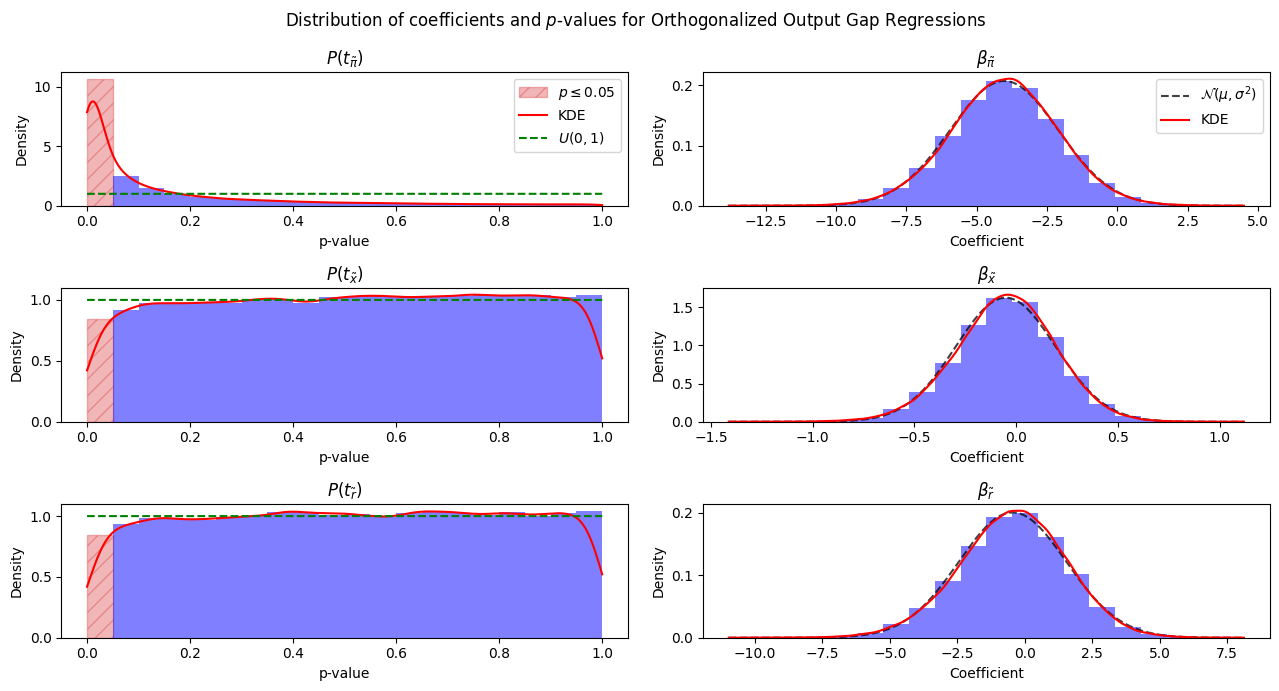

In [16]:
n_bins = 20
uni_range = np.linspace(0, 1, _MC_SAMPLES)
uni_p = np.ones_like(uni_range)

raw_orth = mc_reference["measurement_regressions_orthogonalized_records"]
pi_outgap_orth = raw_orth.loc[(raw_orth["measurement"] == "OutGap") & (raw_orth["predictor"] == "Pi"), :]
x_outgap_orth = raw_orth.loc[(raw_orth["measurement"] == "OutGap") & (raw_orth["predictor"] == "x"), :]
r_outgap_orth = raw_orth.loc[(raw_orth["measurement"] == "OutGap") & (raw_orth["predictor"] == "r"), :]

range_p_pi = np.linspace(pi_outgap_orth["p_value"].min(), pi_outgap_orth["p_value"].max(), _MC_SAMPLES)
kde_p_pi = gaussian_kde(pi_outgap_orth["p_value"])

range_coef_pi = np.linspace(pi_outgap_orth["coef"].min(), pi_outgap_orth["coef"].max(), _MC_SAMPLES)
kde_coef_pi = gaussian_kde(pi_outgap_orth["coef"])
gaus_coef_pi = norm.pdf(range_coef_pi, loc=pi_outgap_orth["coef"].mean(), scale=np.sqrt(pi_outgap_orth["coef"].var()))

range_p_x = np.linspace(x_outgap_orth["p_value"].min(), x_outgap_orth["p_value"].max(), _MC_SAMPLES)
kde_p_x = gaussian_kde(x_outgap_orth["p_value"])

range_coef_x = np.linspace(x_outgap_orth["coef"].min(), x_outgap_orth["coef"].max(), _MC_SAMPLES)
kde_coef_x = gaussian_kde(x_outgap_orth["coef"])
gaus_coef_x = norm.pdf(range_coef_x, loc=x_outgap_orth["coef"].mean(), scale=np.sqrt(x_outgap_orth["coef"].var()))

range_p_r = np.linspace(r_outgap_orth["p_value"].min(), r_outgap_orth["p_value"].max(), _MC_SAMPLES)
kde_p_r = gaussian_kde(r_outgap_orth["p_value"])

range_coef_r = np.linspace(r_outgap_orth["coef"].min(), r_outgap_orth["coef"].max(), _MC_SAMPLES)
kde_coef_r = gaussian_kde(r_outgap_orth["coef"])
gaus_coef_r = norm.pdf(range_coef_r, loc=r_outgap_orth["coef"].mean(), scale=np.sqrt(r_outgap_orth["coef"].var()))

fig, ax = plt.subplots(3, 2, figsize=(_FIGSIZE_2D[0] + 1, _FIGSIZE_2D[1] + 1))
plt.suptitle("Distribution of coefficients and $p$-values for Orthogonalized Output Gap Regressions")

_, _, bins_pi = ax[0, 0].hist(pi_outgap_orth["p_value"], bins=n_bins, density=True, alpha=0.5, color="blue", label="Histogram")
bins_pi[0].set_facecolor("C3")
bins_pi[0].set_edgecolor("C3")
bins_pi[0].set_alpha(0.33)
bins_pi[0].set_hatch("//")
bins_pi[0].set_label(r"$p\leq 0.05$")

ax[0, 0].plot(range_p_pi, kde_p_pi(range_p_pi), color="red", label="KDE")
ax[0, 0].plot(uni_range, uni_p, color="green", linestyle="--", label=r"$U(0,1)$")
ax[0, 0].set_title(r"$P(t_{\tilde{\pi}})$")
ax[0, 0].set_xlabel("p-value")
ax[0, 0].set_ylabel("Density")


ax[0, 1].hist(pi_outgap_orth["coef"], bins=n_bins, density=True, alpha=0.5, color="blue")
ax[0, 1].plot(range_coef_pi, gaus_coef_pi, color="black", alpha=0.75, linestyle="--", label=r"$\mathcal{N}(\mu, \sigma^2)$")
ax[0, 1].plot(range_coef_pi, kde_coef_pi(range_coef_pi), color="red", label="KDE")

ax[0, 1].set_title(r"$\beta_{\tilde{\pi}}$")
ax[0, 1].set_xlabel("Coefficient")
ax[0, 1].set_ylabel("Density")

_, _, bins_x = ax[1, 0].hist(x_outgap_orth["p_value"], bins=n_bins, density=True, alpha=0.5, color="blue")

bins_x[0].set_facecolor("C3")
bins_x[0].set_edgecolor("C3")
bins_x[0].set_alpha(0.33)
bins_x[0].set_hatch("//")
bins_x[0].set_label(r"$p\leq 0.05$")

ax[1, 0].plot(range_p_x, kde_p_x(range_p_x), color="red", label="KDE")
ax[1, 0].plot(uni_range, uni_p, color="green", linestyle="--", label=r"$U(0,1)$")
ax[1, 0].set_title(r"$P(t_{\tilde{x}})$")
ax[1, 0].set_xlabel("p-value")
ax[1, 0].set_ylabel("Density")

ax[1, 1].hist(x_outgap_orth["coef"], bins=n_bins, density=True, alpha=0.5, color="blue")
ax[1, 1].plot(range_coef_x, gaus_coef_x, color="black", alpha=0.75, linestyle="--", label=r"$\mathcal{N}(\mu, \sigma^2)$")
ax[1, 1].plot(range_coef_x, kde_coef_x(range_coef_x), color="red", label="KDE")
ax[1, 1].set_title(r"$\beta_{\tilde{x}}$")
ax[1, 1].set_xlabel("Coefficient")
ax[1, 1].set_ylabel("Density")

_, _, bins_r = ax[2, 0].hist(r_outgap_orth["p_value"], bins=n_bins, density=True, alpha=0.5, color="blue")

bins_r[0].set_facecolor("C3")
bins_r[0].set_edgecolor("C3")
bins_r[0].set_alpha(0.33)
bins_r[0].set_hatch("//")
bins_r[0].set_label(r"$p\leq 0.05$")

ax[2, 0].plot(range_p_r, kde_p_r(range_p_r), color="red", label="KDE")
ax[2, 0].plot(uni_range, uni_p, color="green", linestyle="--", label=r"$U(0,1)$")
ax[2, 0].set_title(r"$P(t_{\tilde{r}})$")
ax[2, 0].set_xlabel("p-value")
ax[2, 0].set_ylabel("Density")

ax[2, 1].hist(r_outgap_orth["coef"], bins=n_bins, density=True, alpha=0.5, color="blue")
ax[2, 1].plot(range_coef_r, gaus_coef_r, color="black", alpha=0.75, linestyle="--", label=r"$\mathcal{N}(\mu, \sigma^2)$")
ax[2, 1].plot(range_coef_r, kde_coef_r(range_coef_r), color="red", label="KDE")
ax[2, 1].set_title(r"$\beta_{\tilde{r}}$")
ax[2, 1].set_xlabel("Coefficient")
ax[2, 1].set_ylabel("Density")

ax[0, 0].legend(loc="upper right")
ax[0, 1].legend(loc="upper right")

plt.tight_layout()
plt.show()

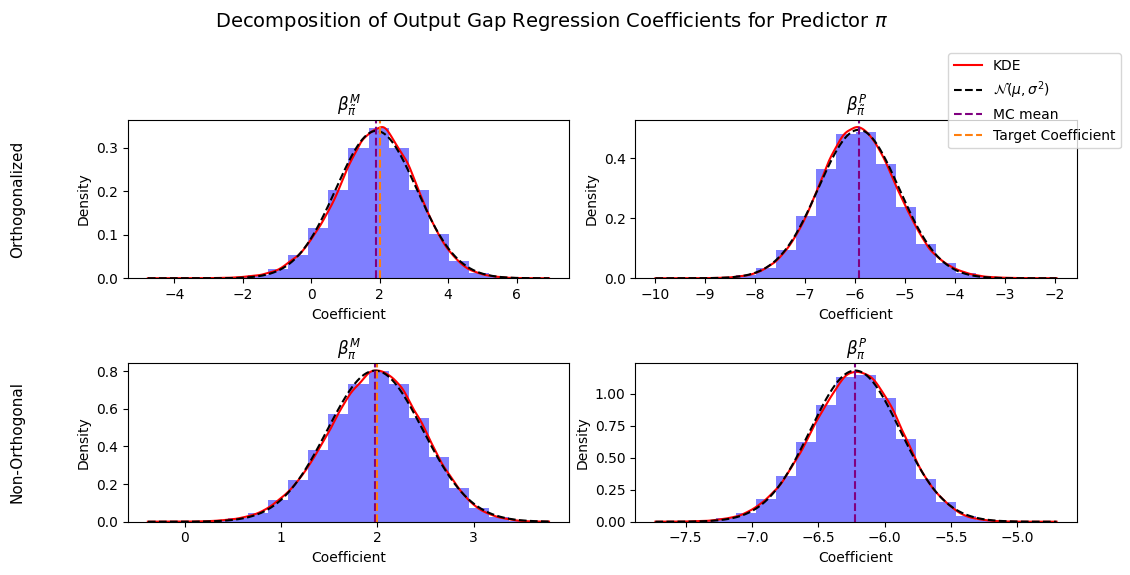

In [17]:
orth_beta_decomp = mc_reference["innovation_decomposition_orthogonalized_records"]
raw_beta_decomp = mc_reference["innovation_decomposition_raw_records"]

orth_decomp_outgap = orth_beta_decomp.loc[orth_beta_decomp["measurement"] == "OutGap", :]
raw_decomp_outgap = raw_beta_decomp.loc[raw_beta_decomp["measurement"] == "OutGap", :]

def get_decomp_variables(df, predictor):
    data = df.loc[df["predictor"] == predictor, :]

    meas_coef = data["beta_measurement_error"].to_numpy()
    state_coef = data["beta_state_prediction_error"].to_numpy()

    def make_density_objects(x):
        x_range = np.linspace(x.min(), x.max(), _MC_SAMPLES)
        kde = gaussian_kde(x)
        gaus = norm.pdf(x_range, loc=x.mean(), scale=np.sqrt(x.var(ddof=1)))
        return x, x_range, kde(x_range), gaus

    meas_objs = make_density_objects(meas_coef)
    state_objs = make_density_objects(state_coef)

    return {
        "meas": meas_objs,
        "state": state_objs,
    }

pi_decomp_orth = get_decomp_variables(orth_decomp_outgap, "Pi")
pi_decomp_raw = get_decomp_variables(raw_decomp_outgap, "Pi")

fig, ax = plt.subplots(2, 2, figsize=_FIGSIZE_2D)
fig.suptitle(
    r"Decomposition of Output Gap Regression Coefficients for Predictor $\pi$",
    fontsize=14
)

def draw_panel(ax, density_obj, title, target=None, show_zero=False):
    vals, xgrid, kde_vals, gaus_vals = density_obj

    ax.hist(vals, bins=n_bins, density=True, alpha=0.5, color="blue")
    ax.plot(xgrid, kde_vals, color="red", label="KDE")
    ax.plot(
        xgrid,
        gaus_vals,
        color="black",
        linestyle="--",
        label=r"$\mathcal{N}(\mu,\sigma^2)$"
    )

    ax.axvline(
        vals.mean(),
        color="purple",
        linestyle="--",
        linewidth=1.5,
        label="MC mean"
    )

    if target is not None:
        ax.axvline(
            target,
            color="C1",
            linestyle="--",
            linewidth=1.5,
            label="Target Coefficient"
        )

    if show_zero:
        ax.axvline(
            0,
            color="gray",
            linestyle=":",
            linewidth=1.3,
            label="Zero"
        )

    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Density")

# Orthogonalized row
draw_panel(
    ax[0, 0],
    pi_decomp_orth["meas"],
    r"$\beta^M_{\tilde{\pi}}$",
    target=2,
)

draw_panel(
    ax[0, 1],
    pi_decomp_orth["state"],
    r"$\beta^P_{\tilde{\pi}}$",
)

# Raw row
draw_panel(
    ax[1, 0],
    pi_decomp_raw["meas"],
    r"$\beta^M_{\pi}$",
    target=2,
)

draw_panel(
    ax[1, 1],
    pi_decomp_raw["state"],
    r"$\beta^P_{\pi}$",
)

# Row labels
ax[0, 0].annotate(
    "Orthogonalized",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    va="center",
    ha="center",
    rotation=90,
    fontsize=11
)

ax[1, 0].annotate(
    "Non-Orthogonal",
    xy=(-0.25, 0.5),
    xycoords="axes fraction",
    va="center",
    ha="center",
    rotation=90,
    fontsize=11
)

# Single shared legend
handles, labels = [], []
for a in ax.flat:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.92)
)

plt.tight_layout(rect=[0.04, 0.03, 0.95, 0.93])
plt.show()

In [18]:
pi_outgap_orth["p_value"].mean().round(3), pi_outgap_orth["p_value"].median().round(3)

(np.float64(0.133), np.float64(0.041))

Monte Carlo summaries above aggregate `_MC_SAMPLES` independent draws. The plots and MCMC output below continue on a representative first draw.


In [19]:
parser_aug = ModelParser(_AUGMENTED_CONFIG)
config_aug, kalman_aug = parser_aug.get_all()
solver_aug = DSGESolver(config_aug, kalman_aug)
comp_aug = solver_aug.compile(
    n_state=3,
    n_exog=3,
)
priors = {
    _AUGMENTED_PARAM: make_prior(
        'normal',
        parameters={"mean": 0.0, "std": 4.0, "random_state": next_seed(_plot_seed_counter)},
        transform="identity",
    ),
}

with STDOUT_VOID():
    mc_aug = summarize_mle_augmentation_experiment(
        sol,
        solver_aug,
        comp_aug,
        sol_dgp,
        mc_reference,
        T=T,
        candidate_param=_AUGMENTED_PARAM,
        mc_samples=_MC_SAMPLES,
        alpha=_MC_ALPHA,
    )

estim = lambda: solver_aug.estimate_and_solve(
    compiled=comp_aug,
    method="mcmc",
    n_draws=25_000,
    burn_in=10_000,
    thin=2,
    posterior_point="mean",
    proposal_scale=1.0,
    y=obs,
    priors=priors,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    random_state=next_seed(_plot_seed_counter),
    **mc_reference["filter_kwargs"],
)
res_aug, sol_aug = estim()

MCMC sampling concluded in 63.02 seconds with 952.01 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


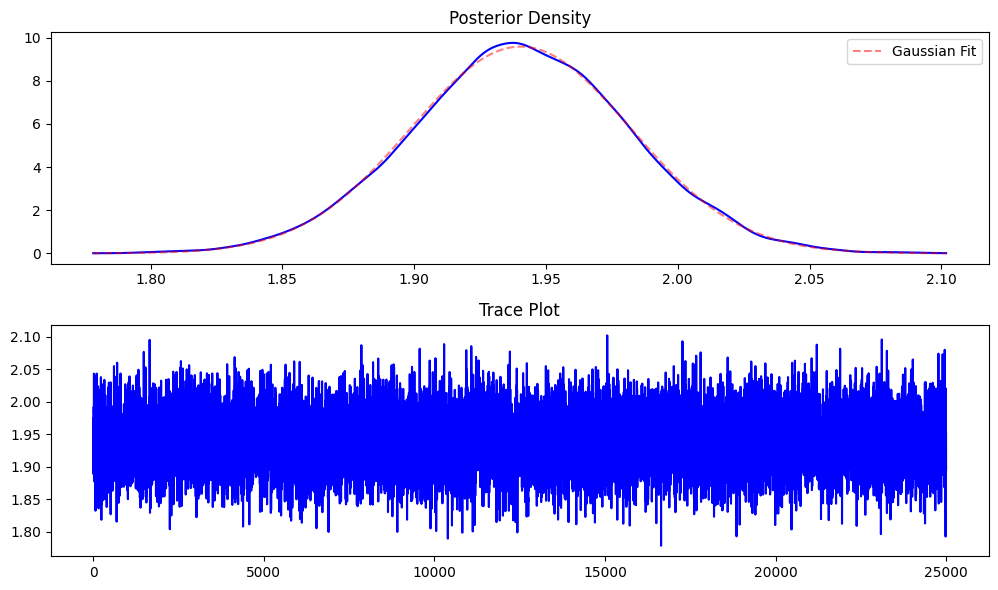

In [20]:
coeff_trace = res_aug.samples[:, 0]

kde = gaussian_kde(coeff_trace)
norm_fit = norm(loc=coeff_trace.mean(), scale=coeff_trace.std())
x_range = np.linspace(coeff_trace.min(), coeff_trace.max(), 1000)
fig, ax = plt.subplots(2, 1, figsize=_FIGSIZE_1D)

ax[0].plot(x_range, kde(x_range), color="blue")
ax[0].plot(x_range, norm_fit.pdf(x_range), linestyle="--", color="red", alpha=0.5, label="Gaussian Fit")
ax[0].set_title("Posterior Density")
ax[0].legend()

ax[1].plot(coeff_trace, color="blue")
ax[1].set_title("Trace Plot")

plt.tight_layout()
plt.show()

In [21]:
sol_aug.config.calibration.parameters[_AUGMENTED_PARAM].round(3)

np.float64(1.94)

In [22]:
tuple(map(lambda x: float(x.round(3)), res_aug.hpd_intervals()[_AUGMENTED_PARAM]))

(1.861, 2.024)

In [23]:
res_aug.accept_rate.round(3)

np.float64(0.445)

In [24]:
kf_aug = sol_aug.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
    **mc_reference["filter_kwargs"],
)
round(kf_aug.loglik, 2)

-782.71

## Diagnostics of the Augmented Model

### Marginal LR Test Conditional on $\theta_0$

In [25]:
print("Monte Carlo LR summary for the MLE-augmented model:")
rep_aug = mc_aug["representative"]
res_mle = rep_aug.res_mle
sol_mle = rep_aug.sol_mle
mle_aug_kf = rep_aug.kf_aug
std_innov_aug_mle = rep_aug.std_innov_aug
sim_aug_mle = rep_aug.sim_aug
mc_aug["lr_summary"].round(3)

Monte Carlo LR summary for the MLE-augmented model:


,estimated_coef,loglik_ref,loglik_aug,lr,p_value,mc_se_estimated_coef,mc_se_loglik_ref,mc_se_loglik_aug,mc_se_lr,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high
0,2.0,-2112.39,-804.826,2615.127,0.0,0.0,0.522,0.055,0.987,0.0,100000,100000,1.0,0.0,1.0,1.0


In [26]:
res_mle

OptimizationResult(kind='mle', x=array([1.94026221]), theta={'beta': np.float64(0.971), 'kappa': np.float64(0.58), 'tau_inv': np.float64(1.86), 'psi_pi': np.float64(2.19), 'psi_x': np.float64(0.3), 'rho_r': np.float64(0.84), 'rho_g': np.float64(0.83), 'rho_z': np.float64(0.85), 'pi_star': np.float64(3.43), 'r_star': np.float64(3.01), 'sig_r': np.float64(0.18), 'sig_g': np.float64(0.18), 'sig_z': np.float64(0.64), 'rho_gz': np.float64(0.36), 'meas_infl': np.float64(1e-06), 'meas_rate': np.float64(1e-06), 'meas_outgap': np.float64(1e-06), 'meas_rho_ir': np.float64(0.0), 'meas_rho_gi': np.float64(0.0), 'meas_rho_gr': np.float64(0.0), 'Pi_coef': np.float64(1.9402622124481006), 'x_coef': np.float64(0.0), 'r_coef': np.float64(0.0)}, success=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', fun=np.float64(782.7052324986445), loglik=np.float64(-782.7052324986445), logprior=np.float64(0.0), logpost=np.float64(-782.7052324986445), nfev=8, nit=3, raw=  message: CONVERGENCE: RE

## Serial Autocorrelation Tests for the Augmented Model

In [27]:
print("Reference moment-specification test summary:")
display(mc_reference["moment_specification_test_summary"].round(3))

print("Augmented moment-specification test summary:")
display(mc_aug["moment_specification_test_summary"].round(3))

print("Reference-minus-augmented moment distance comparison:")
display(mc_aug["moment_specification_comparison"].round(3))

Reference moment-specification test summary:


,test,distance,stat,p_value,mc_se_distance,mc_se_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high,df,sample_size,bandwidth
0,mean_zero_hac,0.120,2.710,0.552,0.000,0.008,0.001,100000,4942,0.049,0.001,0.048,0.051,3.0,200,4
1,cov_identity,13.788,781.796,0.000,0.005,0.994,0.000,100000,100000,1.000,0.000,1.000,1.000,6.0,200,4


Augmented moment-specification test summary:


,test,distance,stat,p_value,mc_se_distance,mc_se_stat,mc_se_p_value,n_replications,n_rejections,reject_rate,reject_rate_mc_se,reject_ci_low,reject_ci_high,df,sample_size,bandwidth
0,mean_zero_hac,0.113,3.313,0.474,0.0,0.009,0.001,100000,7348,0.073,0.001,0.072,0.075,3.0,200,4
1,cov_identity,0.219,7.036,0.468,0.0,0.017,0.001,100000,12067,0.121,0.001,0.119,0.123,6.0,200,4


Reference-minus-augmented moment distance comparison:


,test,n_replications,distance_ref,mc_se_distance_ref,distance_aug,mc_se_distance_aug,distance_improvement,mc_se_distance_improvement,stat_ref,mc_se_stat_ref,stat_aug,mc_se_stat_aug,stat_improvement,mc_se_stat_improvement,aug_closer_rate,aug_closer_rate_mc_se,aug_closer_ci_low,aug_closer_ci_high
0,mean_zero_hac,100000,0.120,0.000,0.113,0.0,0.007,0.000,2.710,0.008,3.313,0.009,-0.603,0.004,0.61,0.002,0.607,0.613
1,cov_identity,100000,13.788,0.005,0.219,0.0,13.569,0.005,781.796,0.994,7.036,0.017,774.760,0.992,1.00,0.000,1.000,1.000
